# Matplotlib Overview


## Introduction

Matplotlib is the foundational plotting library in the Python ecosystem, originally developed by John D. Hunter to provide MATLAB-like plotting capabilities in Python. It offers a rich, programmatic interface for producing publication-quality 2D graphics. For a history and introduction of Matplotlib, see matplotlib.org's [History](https://matplotlib.org/stable/project/history.html) section.

For data scientists, Matplotlib is valuable both as a plotting tool and as the underlying engine for fine-grained customization when presentation quality and plot element control matter.

Matplotlib sits at a low level in the Python visualization stack:

1. Many higher-level libraries, such as Pandas plotting methods and Seaborn, build on top of it.
2. It interoperates smoothly with NumPy arrays and the broader scientific Python toolchain.
3. It can be used through two main interfaces:
   1. The **stateful pyplot API** is convenient for quick, one-off plots.
   2. The **object-oriented (OO) API** is the recommended default for most work because it makes figure and axes management explicit.

A useful rule of thumb is:

- Use `plt.plot()` for quick interactive work.
- Use `plt.subplots()` for most real plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

Matplotlib has excellent official documentation and examples at https://matplotlib.org/ (see the [Tutorials](https://matplotlib.org/stable/tutorials/index.html) and [Examples](https://matplotlib.org/stable/gallery/index.html)).


### Installation 

You'll need to install matplotlib first with either using `pip` in the terminal:

    pip install matplotlib     ### in terminal with .venv enabled
or using `%pip` in the notebook:

    %pip install matplotlib    ### in Jupyter Notebook

Import the `matplotlib.pyplot` module with alias `plt`:
```python
import matplotlib.pyplot as plt
```

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Two Styles of Matplotlib Syntax

There are two common styles of Matplotlib plotting:

1. **Stateful pyplot style**: concise and convenient for quick plots.
2. **Object-oriented (OO) style**: more explicit and easier to scale to multi-axes figures.



Note on rendering visualizations:

- In Jupyter notebooks, plots usually display automatically.
- Outside notebooks, you will often need `plt.show()` to display the figure window.
- In older Jupyter/IPython setups, `%matplotlib inline` may still be needed.



## Stateful Matplotlib

The MATLAB-style pyplot API uses stateful functions such as `plt.plot()`, `plt.xlabel()`, and `plt.title()` to build a figure. It is useful for quick exploration, but it becomes harder to manage as figures grow more complex.


### Basic Matplotlib Commands

The table below compares common `plt.plot()` tasks with the corresponding Pandas `df.plot()` usage.

| Task     | Matplotlib plt.plot()  | Pandas df.plot()                      | Notes                                                           |
|----------|------------------------|---------------------------------------|---------------------------------------------------------------|
| figsize  | `plt.figure(figsize)`  | `df.plot(figsize=(m, n))`             | Use `plt.figure()` to setup figure size before `plt.plot()`     |
| To plot  | `plt.plot(x, y)`       | `df.plot(x="x", y="y")` or `s.plot()` | Uses DataFrame/Series directly; x defaults to index if omitted. |
| X label  | `plt.xlabel("X")`      | `df.plot(xlabel=...)`                 | `df.plot(...)` returns an `Axes`; set labels on it.             |
| Y label  | `plt.ylabel("Y")`      | `df.plot(ylabel=...)`                 | Same pattern as label.                                          |
| Title    | `plt.title("My Plot")` | `df.plot(title="My Plot")`            | Pandas supports `title=` in `plot`                              |


Pandas `.plot()` is a convenience wrapper around Matplotlib for quick DataFrame visualization. Compared with `plt.plot()`, the main differences are:

| Feature | `plt.plot()` | Pandas `.plot()` |
|---------|--------------|-------------|
| Typical use | Fine-grained, figure-level control | Fast EDA from DataFrame/Series |
| Built on | Core matplotlib | Wrapper around matplotlib |
| Customization | Full control | Limited, but can access underlying axes |
| Data Input | Expects x/y arrays | Pandas columns/index |

### First Plots

Let’s walk through a simple example with two NumPy arrays. Lists work too, but you’ll usually pass NumPy arrays or Pandas columns, which behave like arrays. The data we want to plot:

In [86]:
import numpy as np

x = np.linspace(0, 5, 11)     ### 11 numbers from 0 to 5, inclusive
y = x ** 2

print(f"x {type(x)}: {x}")
print(f"y {type(y)}: {y}")

x <class 'numpy.ndarray'>: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
y <class 'numpy.ndarray'>: [ 0.    0.25  1.    2.25  4.    6.25  9.   12.25 16.   20.25 25.  ]


The following code creates a basic line plot:
- `plt.figure()`
- `plt.plot()`

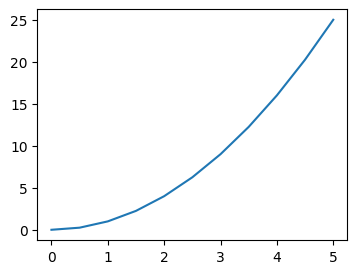

In [87]:
plt.figure(figsize=(4,3))          
plt.plot(x, y)               

You can also create a scatter plot with `plt.scatter()`.


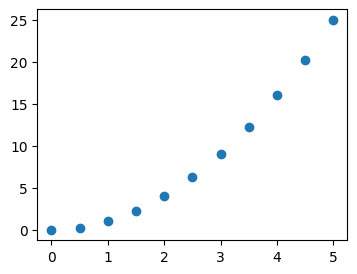

In [88]:
plt.figure(figsize=(4,3))          
plt.scatter(x, y)               

### Labels/Title/Legend

Common plot customizations include:

- color
- label (legend information)
- x-axis and y-axis labels
- title
- legend (built from labels)


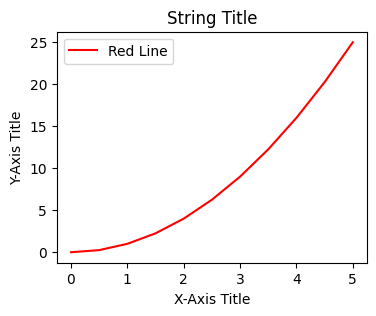

In [89]:
# plt.plot(x, y, 'r')           ### 'r' means color red
# plt.plot(x, y, c='r')         ### same as above, we saw this in Pandas plot

plt.figure(figsize=(4,3))
plt.plot(x, y, c='red', label='Red Line')         ### same as above, we saw this in Pandas plot
plt.xlabel('X-Axis Title')      ### in Pandas plot, this is automatic from column names
plt.ylabel('Y-Axis Title')      ### in Pandas plot, this is automatic from column names
plt.title('String Title')       ### in Pandas plot, this is "title="
plt.legend()                    ### to show the label we set above

The same plot can be created with Pandas plotting:


<Axes: title={'center': 'String Title'}, xlabel='X-Axis Title', ylabel='Y-Axis Title'>

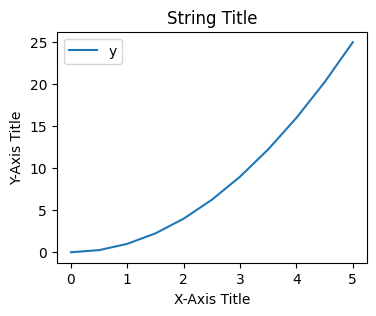

In [90]:
df = pd.DataFrame({'x': x, 'y': y}) ### DataFrame with two columns

# df.plot(x='x', y='y', kind="line")  ### line plot is default in Pandas; axes is automatically created             
# df.plot.line(x='x', y='y')          ### same as above
# df.plot(x='x', y='y')               ### same as above

df.plot(x = 'x', y = 'y', xlabel='X-Axis Title', ylabel='Y-Axis Title', title='String Title', figsize=(4,3))       
### all labels and title can be set in df.plot() directly or from dataframe column names

In [91]:
### Exercise: Basic plt.plot() with Customization
#   1. Create x_vals = np.linspace(0, 10, 50) and y_vals = np.sin(x_vals).
#   2. Use plt.figure(figsize=(4, 3)) to set the figure size.
#   3. Plot sin vs x_vals in red with the label "sin(x)".
#   4. Add an x-label "x", y-label "Amplitude", and title "Sine Wave".
#   5. Call plt.legend() to show the label.
### Your code starts here.




### Your code ends here.

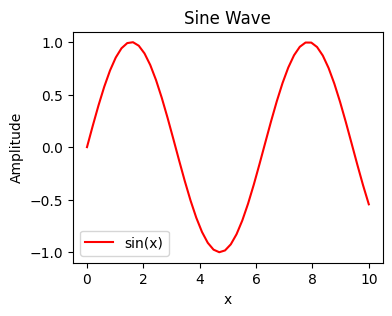

In [92]:
### the data for the plot
x_vals = np.linspace(0, 10, 50)
y_vals = np.sin(x_vals)

### draw the plot with customizations
plt.figure(figsize=(4, 3))              ### this a figure
plt.plot(x_vals, y_vals, c='red', label='sin(x)') ### this is a plot in the figure

### formatting the plot with labels and title
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.title('Sine Wave')
plt.legend()


### Multiple Plots with `plt.subplot()`

`plt.subplot()` is the older pyplot-style way to place multiple axes in one figure. It is still useful to recognize, but for new code you will usually prefer `plt.subplots()`, which is clearer and fits the OO workflow better.

Syntax:

`plt.subplot(nrows, ncols, plot_number)`


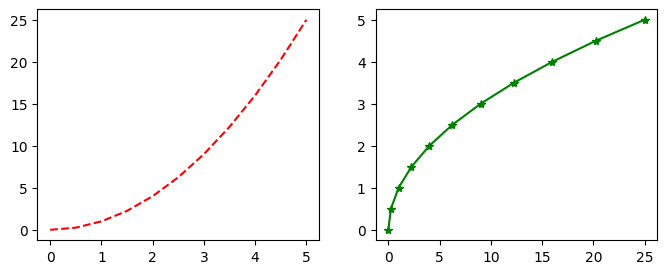

In [93]:
### plt.subplot(nrows, ncols, plot_number)   ### when you want multiple plots in one figure
### order is important, plot after subplot
plt.figure(figsize=(8,3))          ### create a figure first with specified size

plt.subplot(1, 2, 1)     ### subplot (axes, x-by-y) 1 of 1 row, 2 columns
plt.plot(x, y, 'r--')    ### 'r--' means red dashed line

plt.subplot(1, 2, 2)     ### subplot (axes) 2 of 1 row, 2 columns
plt.plot(y, x, 'g*-');   ### 'g*-' means green line with star markers

In [94]:
### Exercise: Multiple Subplots with plt.subplot()
#   1. Create x = np.linspace(0, 2*np.pi, 100).
#   2. Use plt.figure(figsize=(8, 3)) to set the figure size.
#   3. In subplot position (1, 2, 1), plot np.sin(x) with 'b-' and title "Sine".
#   4. In subplot position (1, 2, 2), plot np.cos(x) with 'g--' and title "Cosine".
### Your code starts here.




### Your code ends here.

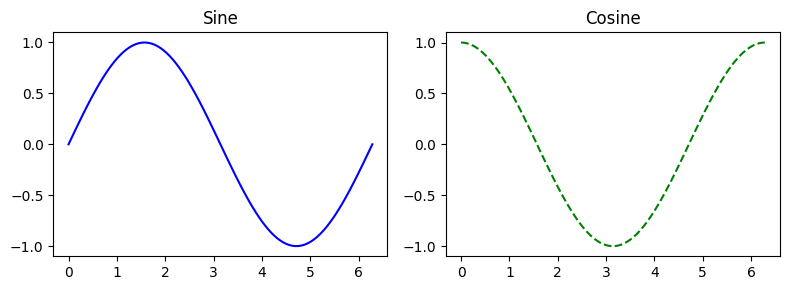

In [95]:
### Solution

x = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(x, np.sin(x), 'b-')
plt.title('Sine')

plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x), 'g--')
plt.title('Cosine')

plt.tight_layout()


## OO API with `plt.subplots()`

Although `plt.plot()` and `plt.subplot()` are useful for quick work, Matplotlib's object-oriented (OO) API is the recommended default for creating plots. In the OO approach, you create **Figure** and **Axes** objects and then call methods on those objects.

This becomes especially helpful when you have multiple subplots, shared axes, or figure-level layout decisions to manage. For example, `ax.set_title()` always targets a specific axes, which is safer than relying on the current pyplot state.



::: {note}
But what's the difference between a **figure** and an **axes**?

| | **Figure** | **Axes** |
|---|---|---|
| Analogy | The full canvas/window | One plot region on that canvas |
| What it is | The top-level container | The area where data is drawn |
| Contains | One or more Axes | X/Y axis, ticks, lines, labels, title, legend |
| Commonly created by | `plt.figure()` or `plt.subplots()` | returned by `plt.subplots()` or added to a figure |

A good mental model is:

```text
Figure
└── Axes (a.k.a. one plot)
    ├── XAxis
    ├── YAxis
    ├── Title
    ├── Lines / Bars / etc.
    └── Legend
```
:::



Here we will learn two OO workflows:

- `plt.subplots()` for the standard, everyday workflow
- `plt.figure()` + `fig.add_axes()` for manual placement and inset-style layouts



### `plt.subplots()`

`plt.subplots()` creates the **figure** and **axes** objects in one step and returns them as a tuple.

- If you create a single subplot, you typically get one `Axes` object.
- If you create multiple subplots, you get a NumPy array of `Axes` objects.

Typical syntax:

`fig, ax = plt.subplots()`

The example below shows the standard one-axes case.


Text(0.5, 1.0, 'Title via Object-Oriented API')

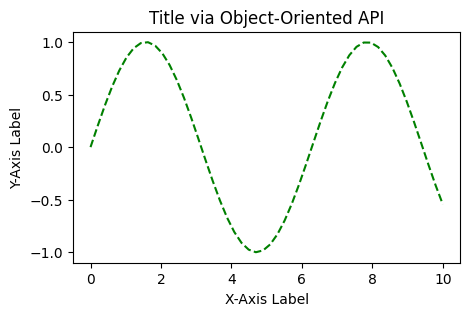

In [96]:

x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

# fig, ax = plt.subplots()              ### single Axes case
# fig, axes = plt.subplots(1, 2)        ### multiple Axes case

fig, ax = plt.subplots(figsize=(5,3))   ### unpacking in one step
ax.plot(x, y, 'g--')                    ### plot on that axes

### common axes methods
ax.set_xlabel('X-Axis Label')
ax.set_ylabel('Y-Axis Label')
ax.set_title('Title via Object-Oriented API')


With `subplots()`, you can specify the number of rows and columns using the `nrows=` and `ncols=` parameters when creating the subplots() object. The example below creates an empty canvas of 1-col by 2-row subplots. 

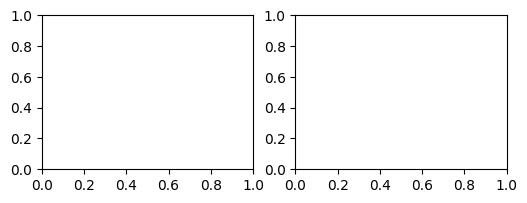

In [97]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)
# fig, axes = plt.subplots(1, 2)            ### same as above

In this example above, `axes` is an array variable containing two `Axes` objects. Looping over that array is a common pattern when you want to apply the same formatting to each subplot.

In [98]:
print(axes)

[<Axes: > <Axes: >]


Now we have access over the two Axes individually using **indexing** (`[0] and [1]`). We may plot them separately.

Text(0.5, 1.0, 'Second Plot')

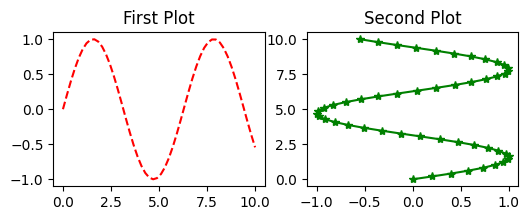

In [99]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

axes[0].plot(x, y, 'r--')    ### plot on the first axes
axes[0].set_title('First Plot')  ### set title for the first axes   

axes[1].plot(y, x, 'g*-')    ### plot on the second axes
axes[1].set_title('Second Plot')  ### set title for the second axes

# plt.show()

It's not uncommon to loop through the Axes object then fine tune the plots.

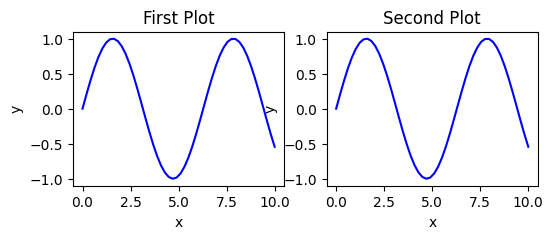

In [100]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

for ax in axes:
    ax.plot(x, y, 'b')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

axes[0].set_title('First Plot')  ### set title for the first axes
axes[1].set_title('Second Plot')  ### set title for the second axes
### display the figure object    
# fig                             ### to show the figure in some environments
plt.show()


A common issue in Matplotlib is overlapping subplot labels or titles. `plt.tight_layout()` can automatically adjust spacing so the figure is easier to read. (compare with the plots above)


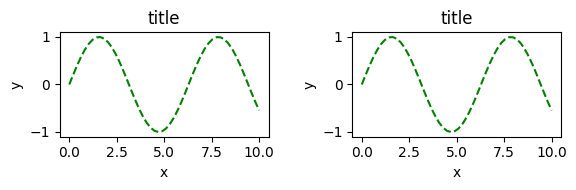

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)

for ax in axes:
    ax.plot(x, y, 'g--')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

fig    
plt.tight_layout()

In [102]:
### Exercise: Side-by-Side Subplots with plt.subplots()
#   1. Use plt.subplots(1, 2, figsize=(8, 3)) to create a figure and two axes.
#   2. On axes[0], plot x vs np.sin(x) with 'b-', title "Sine",
#      x-label "x", and y-label "y".
#   3. On axes[1], plot x vs np.cos(x) with 'r--', title "Cosine",
#      x-label "x", and y-label "y".
#   4. Call plt.tight_layout() at the end.
#   (`x` and `np` are already available above.)
### Your code starts here.




### Your code ends here.

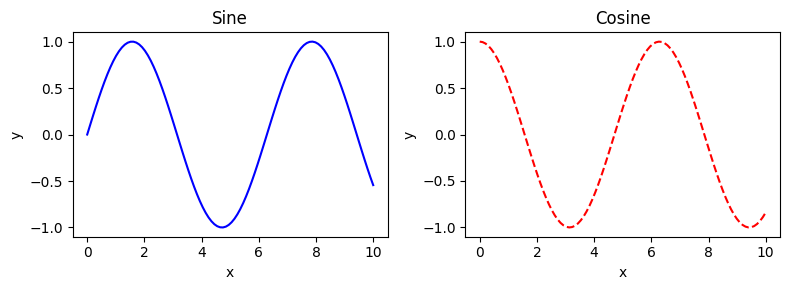

In [103]:
### Solution

x = np.linspace(0, 10, 100)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes.flatten()

ax[0].plot(x, np.sin(x), 'b-')
ax[0].set_title('Sine')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

ax[1].plot(x, np.cos(x), 'r--')
ax[1].set_title('Cosine')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')

plt.tight_layout()


## Plot Appearance


This section focuses on controlling the visible appearance of a figure and Axes.


### Figure-Level Controls

In contrast to `ax` methods, figure-level methods act on the **whole figure** rather than on a single axes. They are especially useful for overall sizing, layout, titles, and exporting.

| Method | What it sets |
|---|---|
| `fig.suptitle('title')` | Master title over all subplots |
| `fig.tight_layout()` | Auto-fix subplot spacing |
| `fig.set_size_inches(w, h)` | Figure size |
| `fig.savefig('file.png')` | Save to file (also `.pdf`, `.svg`, etc.) |
| `fig.set_dpi(150)` | Resolution |
| `fig.subplots_adjust(...)` | Manual spacing (`hspace`, `wspace`, `left`, `right`, ...) |
| `fig.colorbar(mappable, ax=ax)` | Add a colorbar tied to an axes |



### Axes Formatting Methods

After creating a figure and axes, the next step is usually formatting. These methods do not change the underlying data; they control how the plot is labeled, styled, and displayed.

| Method | What it sets |
|---|---|
| `ax.plot(x, y, 'r')` | Plot data (format string: color + linestyle + marker) |
| `ax.set_xlabel('label')` | X-axis label |
| `ax.set_ylabel('label')` | Y-axis label |
| `ax.set_title('title')` | Title above the plot |
| `ax.legend()` | Add a legend to that axes |
| `ax.set_xlim(min, max)` | X-axis range |
| `ax.set_ylim(min, max)` | Y-axis range |
| `ax.grid(True)` | Toggle grid |
| `fig.suptitle('title')` | Master title over all subplots |
| `fig.tight_layout()` | Auto-adjust subplot spacing |


### `subplots()` Parameters



| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `nrows` | int | 1 | Number of subplot rows | `plt.subplots(2, 1)` |
| `ncols` | int | 1 | Number of subplot columns | `plt.subplots(1, 3)` |
| `figsize` | tuple | None | Figure size `(width, height)` in inches | `figsize=(8, 4)` |
| `dpi` | int | rcParams value | Resolution in dots per inch | `dpi=150` |
| `sharex` | bool or str | False | Share x-axis between subplots | `sharex=True` |
| `sharey` | bool or str | False | Share y-axis between subplots | `sharey='row'` |
| `squeeze` | bool | True | Return a scalar vs array of axes when possible | `squeeze=False` |

For a longer reference, see [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).



### `ax.plot()` Parameters

| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `x`, `y` | array-like | — | Data to plot | `ax.plot(x, y)` |
| `color` | str or tuple | auto | Line color | `color='red'` |
| `linewidth` / `lw` | float | 1.5 | Thickness of the line | `lw=2` |
| `linestyle` / `ls` | str | `'-'` | Line style | `ls='--'` |
| `marker` | str | `None` | Marker shape at each data point | `marker='o'` |
| `markersize` / `ms` | float | 6 | Marker size | `ms=8` |
| `markerfacecolor` / `mfc` | str | auto | Fill color of markers | `mfc='white'` |
| `markeredgecolor` / `mec` | str | auto | Edge color of markers | `mec='black'` |
| `alpha` | float | 1.0 | Transparency (0 = invisible, 1 = opaque) | `alpha=0.7` |
| `label` | str | `None` | Legend label for the line | `label='Series A'` |
| `zorder` | float | auto | Drawing order (higher = on top) | `zorder=5` |

Common `linestyle` values: `'-'` (solid), `'--'` (dashed), `'-.'` (dash-dot), `':'` (dotted).  
Common `marker` values: `'o'` (circle), `'s'` (square), `'^'` (triangle), `'x'` (cross), `'+'` (plus), `'.'` (point).

For a full reference, see [matplotlib.axes.Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html).



## Styling in Practice

#### `figsize=` at Figure Level

Figure size and DPI are two of the most common figure-level controls.

- `figsize=(width, height)` uses inches.

This can be set with `plt.figure(...)` or `plt.subplots(...)`.


Text(0.5, 1.0, 'title')

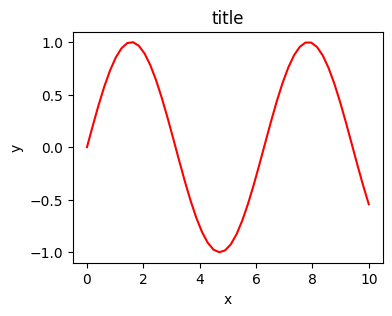

In [ ]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

fig, axes = plt.subplots(figsize=(4,3))

### peripherals for the axes object
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

#### Legends for Axes



Legends are attached to an **axes** in the OO API. You typically supply `label=...` when plotting, then call `ax.legend()` to display the legend for that axes.


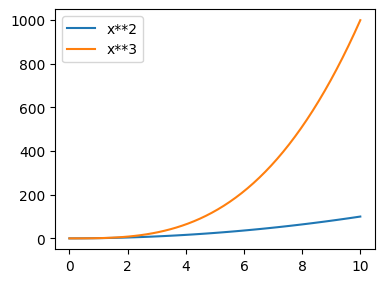

In [105]:

fig = plt.figure(figsize=(4,3), dpi=100)

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot(x, x**2, label="x**2")
ax.plot(x, x**3, label="x**3")      ### cubed
ax.legend()



If the legend overlaps the plotted data, pass a `loc=` argument to `ax.legend()` to move it.

Common values include string labels such as `'best'`, `'upper right'`, `'upper left'`, `'lower left'`, and `'lower right'`.


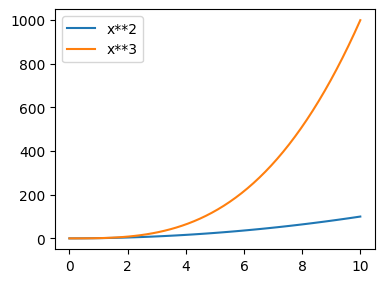

In [106]:
# Common legend locations

# ax.legend(loc='upper right')
# ax.legend(loc='upper left')
# ax.legend(loc='lower left')
# ax.legend(loc='lower right')

ax.legend(loc='best')
fig


#### Plot Range `set_xlim(), set_ylim()`

You can set axis ranges directly with `ax.set_xlim(...)` and `ax.set_ylim(...)`, or use `ax.axis('tight')` to fit the view closely around the data. 

In the example below, `axes[2] is **zoomed in**, only showing the slice of the data where x is between 2 and 5, and y is between 0 and 60. That's why it looks different from the first two even though it plots the same data.

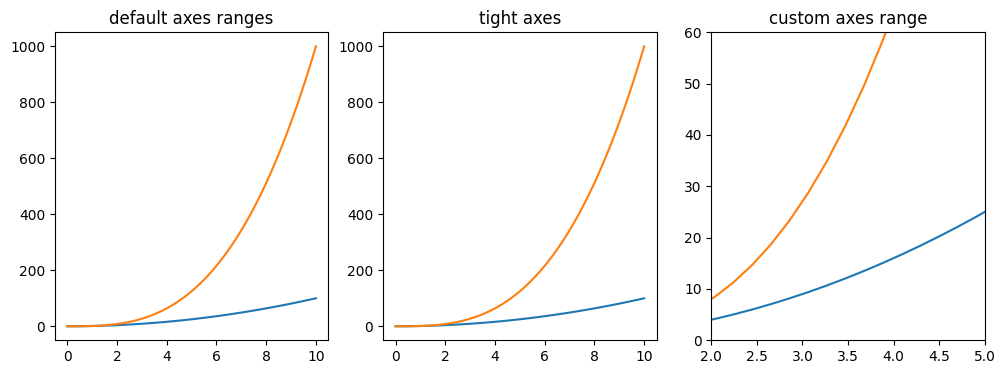

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x, x**2, x, x**3)
axes[0].set_title("default axes ranges")

axes[1].plot(x, x**2, x, x**3)
axes[1].axis('tight')
axes[1].set_title("tight axes")

axes[2].plot(x, x**2, x, x**3)
axes[2].set_ylim([0, 60])       # y-axis runs from 0 to 60
axes[2].set_xlim([2, 5])        # x-axis runs from 2 to 5
axes[2].set_title("custom axes range");

In [108]:
### Exercise: Controlling Axis Ranges
#   1. Use fig, axes = plt.subplots(1, 2, figsize=(10, 4)).
#   2. On axes[0], plot x vs x**2 and x vs x**3. Set title "Default Range".
#   3. On axes[1], plot the same data, then set:
#      - x-axis limits to [1, 4] using set_xlim
#      - y-axis limits to [0, 80] using set_ylim
#      Set title "Custom Range".
#   4. Call plt.tight_layout() at the end.
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

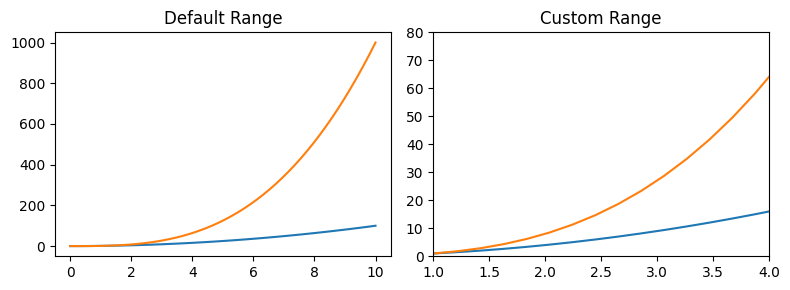

In [109]:
### Solution

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].plot(x, x**2, x, x**3)
axes[0].set_title('Default Range')

axes[1].plot(x, x**2, x, x**3)
axes[1].set_xlim([1, 4])
axes[1].set_ylim([0, 80])
axes[1].set_title('Custom Range')

plt.tight_layout()

#### Colors, Line Width and Style

Matplotlib gives you many options for customizing colors, line widths, and line styles.


#### MATLAB-style format strings



Matplotlib supports short MATLAB-style format strings such as `'b.-'`, which combine color, line style, and marker style in one compact argument.


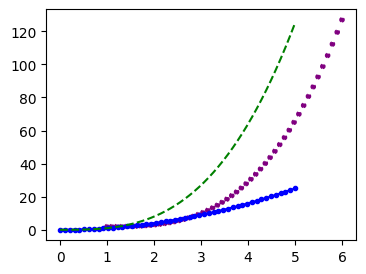

In [149]:
### MATLAB style line color and style 
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(x, x**2, 'b.-')         # blue line with dots
ax.plot(x, x**3, 'g--')         # green dashed line

### .plot() parameters can also be specified in a more explicit way
ax.scatter(x+1, x**3 + 2, color='purple', marker='.', linestyle='--')   # more explicit

In [111]:
### Exercise: MATLAB-Style Color and Line Formatting
#   1. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   2. Plot x vs np.sin(x) using 'b.-' (blue line with dots).
#   3. Plot x vs np.cos(x) using 'r--' (red dashed line).
#   4. Set the title to "MATLAB-Style Colors".
#   (x and np are already available above.)
### Your code starts here.




### Your code ends here.

Text(0.5, 1.0, 'MATLAB-Style Colors')

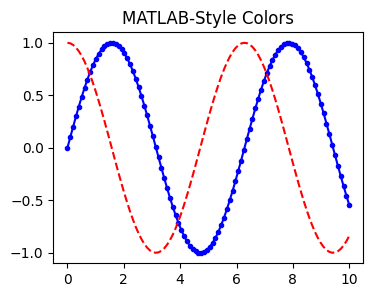

In [112]:
### Solution

x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, np.sin(x), 'b.-')
ax.plot(x, np.cos(x), 'r--')
ax.set_title('MATLAB-Style Colors')


#### The `color=` Parameter



You can also define colors by name or by RGB hex code, and control transparency with `alpha`.


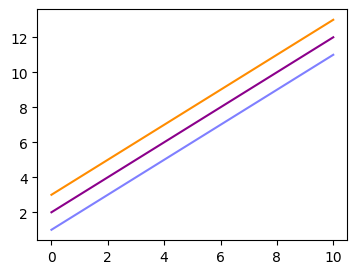

In [113]:
fig, ax = plt.subplots(figsize=(4,3), dpi=100)

ax.plot(x, x+1, color="blue", alpha=0.5)  ### half-transparent
ax.plot(x, x+2, color="#8B008B")        ### RGB hex code
ax.plot(x, x+3, color="#FF8C00")        ### RGB hex code 

In [114]:
### Exercise: Colors with the color= Parameter and Alpha
#   1. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   2. Plot x vs x+1 with color="blue" and alpha=0.3.
#   3. Plot x vs x+2 with color="#228B22" (forest green) and alpha=0.7.
#   4. Plot x vs x+3 with color="tomato" and alpha=1.0.
#   5. Set the title to "Color and Transparency".
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

Text(0.5, 1.0, 'Color and Transparency')

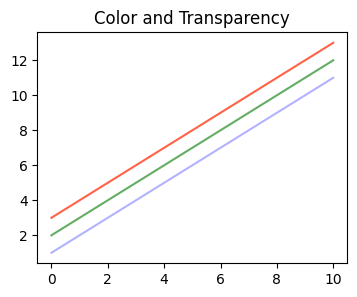

In [115]:
### Solution

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, x + 1, color="blue", alpha=0.3)
ax.plot(x, x + 2, color="#228B22", alpha=0.7)
ax.plot(x, x + 3, color="tomato", alpha=1.0)
ax.set_title("Color and Transparency")


#### Line and marker styles



To change line width, use `linewidth` or `lw`. To change line style, use `linestyle` or `ls`. Marker shape, size, and colors can also be customized.


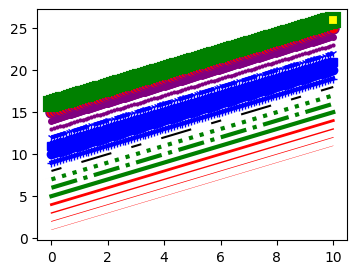

In [116]:
fig, ax = plt.subplots(figsize=(4,3))

ax.plot(x, x+1, color="red", linewidth=0.25)
ax.plot(x, x+2, color="red", linewidth=0.50)
ax.plot(x, x+3, color="red", lw=1.00)
ax.plot(x, x+4, color="red", lw=2.00)

### possible linestype options ‘-‘, ‘–’, ‘-.’, ‘:’, or ‘None’ (the default, which means no line will be drawn). 
ax.plot(x, x+5, color="green", lw=3, linestyle='-')
ax.plot(x, x+6, color="green", lw=3, ls='-.')
ax.plot(x, x+7, color="green", lw=3, ls=':')

### custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10])        ### format: line length, space length, ...

### possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="blue", lw=3, ls='-', marker='+')
ax.plot(x, x+10, color="blue", lw=3, ls='--', marker='o')
ax.plot(x, x+11, color="blue", lw=3, ls='-', marker='s')
ax.plot(x, x+12, color="blue", lw=3, ls='--', marker='1')

### marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green");

In [117]:
### Exercise: Line Width, Style, and Markers
#   1. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   2. Plot x vs x+1: color='red', lw=2, ls='-', marker='o'.
#   3. Plot x vs x+3: color='green', lw=1, ls='--', marker='s'.
#   4. Plot x vs x+5: color='blue', lw=3, ls=':', marker='^',
#      markersize=8, markerfacecolor='yellow'.
#   5. Set the title to "Line and Marker Styles".
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

Text(0.5, 1.0, 'Line and Marker Styles')

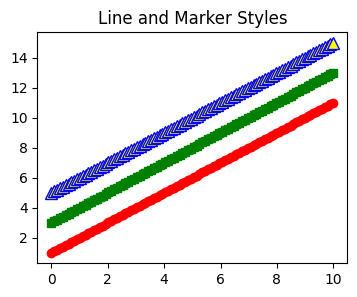

In [118]:
### Solution

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, x + 1, color='red', lw=2, ls='-', marker='o')
ax.plot(x, x + 3, color='green', lw=1, ls='--', marker='s')
ax.plot(x, x + 5, color='blue', lw=3, ls=':', marker='^',
        markersize=8, markerfacecolor='yellow')
ax.set_title('Line and Marker Styles')

### Common Plot Types

So far we have used line plots to introduce Matplotlib. Below are a few common plot types, shown in the OO style so the examples stay consistent with the rest of the notebook.



#### Scatter Plot

A **scatter plot** displays individual data points as dots on a two-dimensional plane, with one variable on the x-axis and another on the y-axis. Each dot represents a single observation. Scatter plots are useful for visualizing the relationship or correlation between two continuous variables, and for identifying patterns, clusters, or outliers in the data.


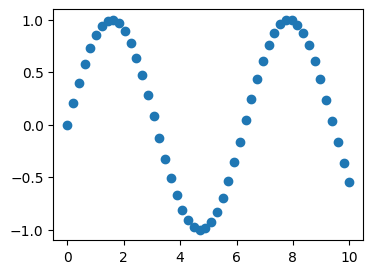

In [119]:
x = np.linspace(0, 10, 50)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(x, y)


#### Bar Plot

A **bar plot** displays categorical data as rectangular bars, where the height (or length) of each bar is proportional to the value it represents. The x-axis typically shows the categories and the y-axis shows the corresponding values. Bar plots are useful for comparing quantities across distinct groups or categories.


Text(0.5, 1.0, 'Simple Bar Plot')

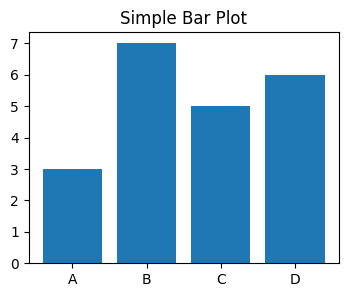

In [120]:
categories = ['A', 'B', 'C', 'D']
values = [3, 7, 5, 6]

fig, ax = plt.subplots(figsize=(4,3))
ax.bar(categories, values)
ax.set_title('Simple Bar Plot')



#### Histogram

A **histogram** displays the distribution of a continuous variable by dividing the data into bins (intervals) and counting how many values fall into each bin. The x-axis represents the value ranges, and the y-axis represents the frequency (count) of observations in each bin. Histograms are useful for visualizing the shape of a distribution — whether it is symmetric, skewed, or has multiple peaks.


(array([12.,  7., 14., 15., 10., 12.,  7.,  5., 10.,  8.]),
 array([ 16., 114., 212., 310., 408., 506., 604., 702., 800., 898., 996.]),
 <BarContainer object of 10 artists>)

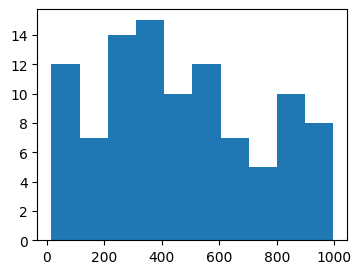

In [121]:
from random import sample
data = sample(range(1, 1000), 100)     ### chooses 100 unique random elements from sequence.

fig, ax = plt.subplots(figsize=(4,3))
ax.hist(data)


#### Boxplot

A **boxplot** (also called a box-and-whisker plot) summarizes the distribution of a dataset using five key statistics: 

- the minimum, 
- first quartile (Q1), 
- median, 
- third quartile (Q3), and 
- maximum. 

Also:
- The box: The box spans from Q1 to Q3 (the **interquartile** range, IQR)
- The line: the line inside the box marks the **median**. 
- The whiskers: The whiskers extend to the last data points within **1.5 × IQR** from Q1 and Q3. 
- Points/circles beyond the whiskers are plotted individually as **outliers**. 

Boxplots are useful for comparing distributions across multiple groups.

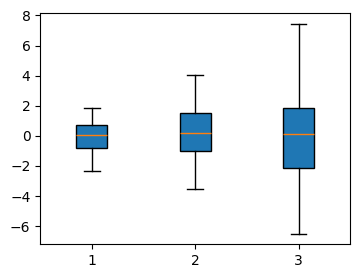

In [152]:
### list comprehension to create multiple datasets with different standard deviations
data = [np.random.normal(0, std, 100) for std in range(1, 4)]

fig, ax = plt.subplots(figsize=(4,3))

### rectangular box plot
ax.boxplot(data, vert=True, patch_artist=True);   

In [ ]:
### Exercise: Visualizing Sales Data with Different Plot Types
#   The following data represent quarterly sales figures ($K) for four products
#   and daily website visits over 100 days.
#
#   products = ['Laptop', 'Phone', 'Tablet', 'Watch']
#   sales    = [320, 580, 140, 210]
#   visits   = np.random.normal(loc=500, scale=80, size=100)
#
#   1. Create a figure with two side-by-side subplots: fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#   2. On ax1, draw a bar chart of products vs. sales.
#      Set the title to "Quarterly Product Sales", x-label "Product", y-label "Sales ($K)".
#   3. On ax2, draw a histogram of visits using ax2.hist(visits, bins=15), 
#      color='orange', edgecolor='white', and alpha=0.7.
#      Set the title to "Daily Website Visits", x-label "Visits", y-label "Frequency".
#   4. Call plt.tight_layout() before displaying.
### Your code starts here.




### Your code ends here.


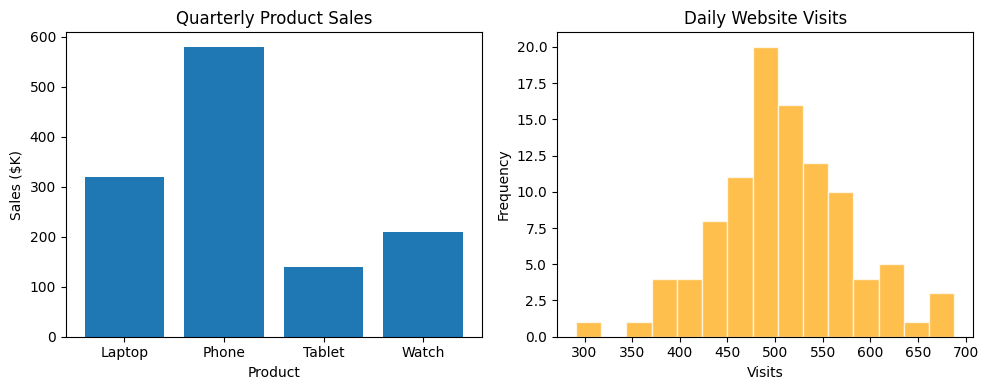

In [170]:
### Solution

products = ['Laptop', 'Phone', 'Tablet', 'Watch']
sales    = [320, 580, 140, 210]
visits   = np.random.normal(loc=500, scale=80, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(products, sales)
ax1.set_title('Quarterly Product Sales')
ax1.set_xlabel('Product')
ax1.set_ylabel('Sales ($K)')

ax2.hist(visits, bins=15, color='orange', edgecolor='white', alpha=0.7)
ax2.set_title('Daily Website Visits')
ax2.set_xlabel('Visits')
ax2.set_ylabel('Frequency')

plt.tight_layout()


### Saving Figures

Matplotlib can save high-quality output in formats such as PNG, JPG, SVG, and PDF.



Use the figure's `savefig` method. In the example below, we create a small figure explicitly before saving it:


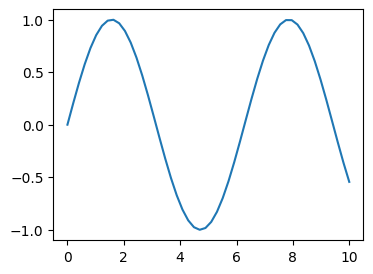

In [125]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y)
fig.savefig("../../images/filename.png")


A slightly safer pattern is to build the output path first and save only if needed:


File already exists, skipping: ../../images/filename.png


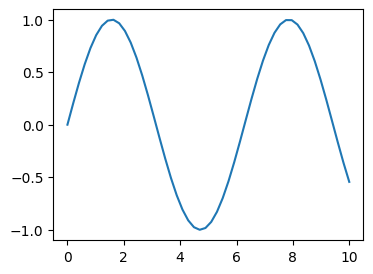

In [126]:
import os

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y)


output_dir = '../../images'
output_file = os.path.join(output_dir, 'filename.png')

if not os.path.exists(output_dir):          # check folder
    os.makedirs(output_dir)

if not os.path.isfile(output_file):         # check file
    fig.savefig(output_file)
    print(f"Saved: {output_file}")
else:
    print(f"File already exists, skipping: {output_file}")

# fig.savefig(output_file)


## OO with `add_axes()`

`fig.add_axes()` is a more manual OO technique than `plt.subplots()`. It is most useful when you want precise axes placement, such as inset plots or custom layouts.

The process of using `add_axes()` to create plots is:

1. Create a **Figure** object.
2. Add one or more **Axes** using normalized figure coordinates `[left, bottom, width, height]`.
3. Plot and format each axes separately.


`add_axes()` uses normalized figure coordinates. For example, `[0.1, 0.1, 0.8, 0.8]` means:

- left edge at 10% of the figure width
- bottom edge at 10% of the figure height
- axes width equal to 80% of the figure width
- axes height equal to 80% of the figure height


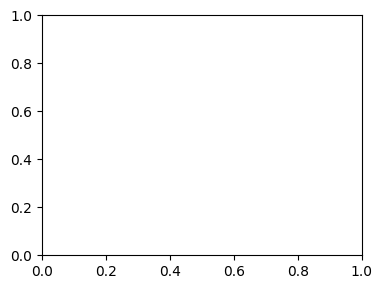

In [127]:
fig = plt.figure(figsize=(4,3))             ### 1. create an empty figure
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### 2. add one axes using normalized coordinates



While slightly more involved, `add_axes()` gives you precise control over where each axes sits in the figure. That makes it a good choice for inset plots and manually arranged layouts.


Text(0.5, 1.0, 'Axes 2 Title')

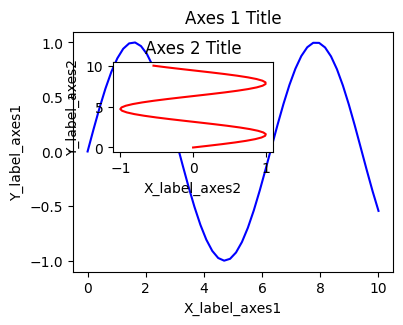

In [128]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

fig = plt.figure(figsize=(4,3))         ### create empty canvas on the figure (object)

### add two axes to the figure
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### main axes
axes2 = fig.add_axes([0.2, 0.5, 0.4, 0.3])     ### insert axes

### larger figure Axes 1
axes1.plot(x, y, 'b')
axes1.set_xlabel('X_label_axes1')
axes1.set_ylabel('Y_label_axes1')
axes1.set_title('Axes 1 Title')

### insert figure Axes 2
axes2.plot(y, x, 'r')
axes2.set_xlabel('X_label_axes2')
axes2.set_ylabel('Y_label_axes2')
axes2.set_title('Axes 2 Title')

In [129]:
### Exercise: Figure with Main Plot and Inset using plt.figure()
#   1. Create a figure with figsize=(4, 3).
#   2. Add a main axes at [0.1, 0.1, 0.8, 0.8] and plot x vs x**2 in blue.
#      Set the title to "Main: x squared".
#   3. Add an inset axes at [0.55, 0.15, 0.3, 0.3] and plot x vs x**3 in red.
#      Set the title to "Inset: x cubed".
#   (x = np.linspace(0, 5, 50) is already defined above.)
### Your code starts here.




### Your code ends here.

Text(0.5, 1.0, 'Inset: x cubed')

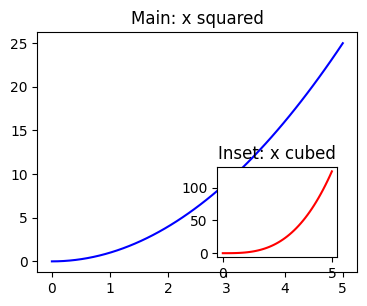

In [130]:
### Solution

x = np.linspace(0, 5, 50)

fig = plt.figure(figsize=(4, 3))

main_ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
main_ax.plot(x, x**2, 'b')
main_ax.set_title('Main: x squared')

inset_ax = fig.add_axes([0.55, 0.15, 0.3, 0.3])
inset_ax.plot(x, x**3, 'r')
inset_ax.set_title('Inset: x cubed')

### DPI

- `dpi` sets dots per inch, which affects rendered resolution.

Text(0.5, 1.0, 'title')

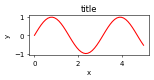

In [131]:
fig = plt.figure(figsize=(3,1), dpi=50)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

Text(0.5, 1.0, 'title')

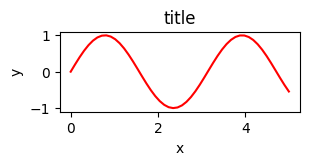

In [132]:
fig = plt.figure(figsize=(3,1), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

In [133]:
### Exercise: Setting Figure Size and DPI
#   1. Create a figure with figsize=(4, 3) and dpi=150.
#   2. Add axes using fig.add_axes([0.1, 0.1, 0.8, 0.8]).
#   3. Plot x vs x**2 with a green line.
#   4. Set the title to "High-Resolution Plot".
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

Text(0.5, 1.0, 'High-Resolution Plot')

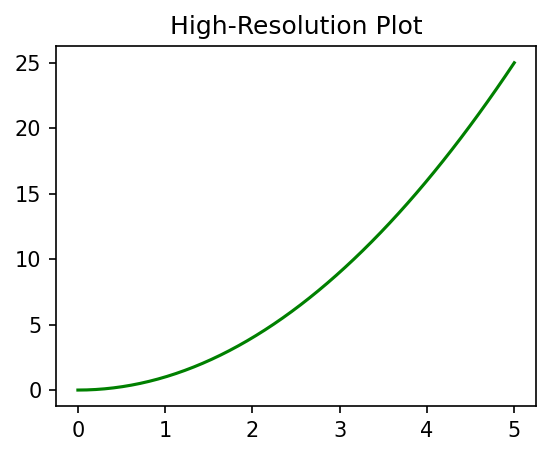

In [134]:
### Solution

fig = plt.figure(figsize=(4, 3), dpi=150)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(x, x**2, 'g')
ax.set_title('High-Resolution Plot')

### Recap

A practical way to choose among the main Matplotlib workflows is:

- Use `plt.plot()` for quick, one-off exploration.
- Use `plt.subplots()` for most plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.
